# Task 1 — Exploratory Data Analysis
## Uber Fare Prediction Project

**Objective:** Deeply understand the data before building any model, by asking questions, choosing the most appropriate plot for each one, and writing a clear interpretation.

## 0. Setup & Load Data

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('/content/final_internship_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (500000, 26)


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


## 1. Initial Inspection

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

In [43]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nFull duplicate rows:", df.duplicated().sum())

Missing values per column:
dropoff_longitude    5
dropoff_latitude     5
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64

Full duplicate rows: 0


In [44]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000
mean,11.358361,-1.265712,0.696740,-1.265755,0.696675,1.683428,13.510834,15.684206,6.268650,3.042008,2011.739132,385.279367,380.503657,363.843772,363.674038,355.991423,19.468775,0.297145
std,9.916617,0.206941,0.140909,0.205903,0.128997,1.307395,6.511571,8.681066,3.437815,1.949240,1.860889,2419.087483,2428.804740,2425.075903,2428.348683,2428.730839,367.299601,1.804548
min,-44.900000,-52.119764,-54.389440,-59.049665,-44.676047,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141593
25%,6.000000,-1.291405,0.710958,-1.291393,0.710943,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.341514,32.173712,17.100762,14.886989,7.147384,1.214550,-0.854721
50%,8.500000,-1.291226,0.711268,-1.291197,0.711277,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.523163,34.787507,19.591554,18.347580,10.458151,2.116970,-0.050442
75%,12.500000,-1.290970,0.711520,-1.290908,0.711538,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.785649,38.304502,22.214815,22.417812,14.448699,3.890070,2.206769
max,500.000000,37.360538,29.724576,0.712985,7.061893,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,30133.067880,30167.595967,30167.285794,30159.407296,30162.285356,12399.956433,3.141593


**Initial notes:**
- No missing values in any column.
- No fully duplicated rows.
- `pickup/dropoff longitude & latitude`: values are very small (e.g. -1.29) — these are in **radians, not degrees**. We'll convert them during cleaning.
- We still need to check negative fares, zero passengers, zero/extreme distances, and unrealistic fares before plotting anything.

## 2. Preprocessing (Full Data Cleaning)

### 2.1 Remove missing/duplicate rows (safety step)
Even though the initial check found zero, this is standard practice.

In [45]:
df_clean = df.dropna().drop_duplicates().copy()
print("Shape after dropna & drop_duplicates:", df_clean.shape)

Shape after dropna & drop_duplicates: (499995, 26)


### 2.2 Remove negative fare_amount
A negative fare is not physically possible — this is a confirmed data error.

In [46]:
print("Negative fares:", (df_clean['fare_amount'] < 0).sum())
df_clean = df_clean[df_clean['fare_amount'] >= 0].copy()
print("Shape after removing negative fares:", df_clean.shape)

Negative fares: 21
Shape after removing negative fares: (499974, 26)


### 2.3 Remove trips with passenger_count = 0
A ride with zero passengers doesn't make sense.

In [47]:
print("Zero passengers:", (df_clean['passenger_count'] == 0).sum())
df_clean = df_clean[df_clean['passenger_count'] > 0].copy()
print("Shape after removing zero passengers:", df_clean.shape)

Zero passengers: 1791
Shape after removing zero passengers: (498183, 26)


### 2.4 Convert coordinates from radians to degrees
The raw values (e.g. -1.29) aren't geographically interpretable. After conversion, values should look realistic for NYC (longitude ≈ -74, latitude ≈ 40.7).

In [48]:
coord_cols = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
for col in coord_cols:
    df_clean[col] = np.degrees(df_clean[col])

df_clean[coord_cols].describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
count,498183.000000,498183.000000,498183.000000,498183.000000
mean,-72.519245,39.919780,-72.521607,39.915940
std,11.864330,8.081898,11.805071,7.397781
min,-2986.242495,-3116.285383,-3383.296608,-2559.748913
25%,-73.992048,40.734913,-73.991382,40.734054
50%,-73.981784,40.752667,-73.980126,40.753152
75%,-73.967115,40.767074,-73.963572,40.768132
max,2140.601160,1703.092772,40.851027,404.616667


### 2.5 Detect and remove invalid zero-location coordinates
If distance = 0 **and** all coordinates are near zero, this indicates a complete GPS error (a point in the ocean), not a real trip.

In [49]:
zero_distance = df_clean[df_clean['distance'] == 0]
print("Total zero-distance trips:", len(zero_distance))

invalid_zero_location = (
    (df_clean['distance'] == 0) &
    (df_clean['pickup_longitude'].abs() < 1) &
    (df_clean['pickup_latitude'].abs() < 1) &
    (df_clean['dropoff_longitude'].abs() < 1) &
    (df_clean['dropoff_latitude'].abs() < 1)
)
print("Invalid zero-location rows:", invalid_zero_location.sum())

df_clean = df_clean[~invalid_zero_location].copy()
print("Shape after removing invalid zero-location rows:", df_clean.shape)

Total zero-distance trips: 14222
Invalid zero-location rows: 8970
Shape after removing invalid zero-location rows: (489213, 26)


### 2.6 Detect and remove coordinates outside a realistic NYC bounding box
Any coordinate outside the rough NYC bounding box (longitude -75 to -72, latitude 40 to 42) is most likely a data-entry error (e.g. longitude and latitude swapped).

In [50]:
nyc_bounds = dict(lon_min=-75, lon_max=-72, lat_min=40, lat_max=42)

mask_valid_coords = (
    df_clean['pickup_longitude'].between(nyc_bounds['lon_min'], nyc_bounds['lon_max']) &
    df_clean['pickup_latitude'].between(nyc_bounds['lat_min'], nyc_bounds['lat_max']) &
    df_clean['dropoff_longitude'].between(nyc_bounds['lon_min'], nyc_bounds['lon_max']) &
    df_clean['dropoff_latitude'].between(nyc_bounds['lat_min'], nyc_bounds['lat_max'])
)
print("Rows with out-of-bound coordinates:", (~mask_valid_coords).sum())

df_clean = df_clean[mask_valid_coords].copy()
print("Shape after removing bad coordinates:", df_clean.shape)

Rows with out-of-bound coordinates: 1416
Shape after removing bad coordinates: (487797, 26)


### 2.7 Detect and remove extreme distances (> 100 km)
A trip longer than 100 km within NYC is unlikely and probably a calculation error.

In [51]:
print("Trips with distance > 100 km:", (df_clean['distance'] > 100).sum())
df_clean = df_clean[df_clean['distance'] <= 100].copy()
print("Shape after removing extreme distances:", df_clean.shape)

Trips with distance > 100 km: 21
Shape after removing extreme distances: (487776, 26)


### 2.8 Inspect unrealistic fares
Let's look at trips with a very high fare, and check whether they make sense relative to distance.

In [52]:
high_fare = df_clean[df_clean['fare_amount'] > 100]
print("Trips with fare > 100:")
print(high_fare[['fare_amount', 'distance', 'passenger_count']])

Trips with fare > 100:
        fare_amount   distance  passenger_count
1335         180.00   0.000000                1
1483         165.00   0.028489                1
12349        104.67  43.648755                1
14142        108.00   3.828609                1
20886        120.00   0.000000                2
...             ...        ...              ...
485576       105.50  33.847743                2
486557       102.00   0.011119                3
486880       140.00   0.003367                1
493018       104.40  23.089234                1
494480       208.00   0.000000                3

[187 rows x 3 columns]


We found trips with a very high fare paired with a distance close to zero — this doesn't make sense, so we'll remove clearly unrealistic fares (above a reasonable cap of $180).

In [53]:
before = df_clean.shape[0]
df_clean = df_clean[df_clean['fare_amount'] <= 180].copy()
print(f"Removed {before - df_clean.shape[0]} rows with unrealistic fares")

Removed 31 rows with unrealistic fares


### 2.9 Convert pickup_datetime to a real datetime type

In [54]:
df_clean['pickup_datetime'] = pd.to_datetime(df_clean['pickup_datetime'])
df_clean.dtypes[['pickup_datetime']]

,0
pickup_datetime,datetime64[ns]


### 2.10 Final cleaning summary

In [55]:
print("Final cleaned shape:", df_clean.shape)
print(f"Total rows removed: {df.shape[0] - df_clean.shape[0]} out of {df.shape[0]}")
df_clean.describe()

Final cleaned shape: (487745, 26)
Total rows removed: 12255 out of 500000


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,487745.000000,487745,487745.000000,487745.000000,487745.000000,487745.000000,487745.000000,487745.000000,487745.000000,487745.000000,487745.000000,487745.000000,487745.000000,487745.000000,487745.000000,487745.000000,487745.000000,487745.000000,487745.000000
mean,11.333739,2012-03-20 15:44:38.962373376,-73.975193,40.750996,-73.974196,40.751400,1.690076,13.511997,15.678432,6.271915,3.041934,2011.737927,41.888845,35.701154,19.588335,18.936891,11.199839,3.331501,0.304042
min,0.000000,2009-01-01 00:31:32,-74.968142,40.052722,-74.964263,40.041180,1.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141550
25%,6.000000,2010-08-14 12:06:25,-73.992265,40.736550,-73.991567,40.735610,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.306751,32.118566,17.038435,14.809068,7.074032,1.255677,-0.877957
50%,8.500000,2012-03-21 08:39:00,-73.982079,40.753385,-73.980579,40.753885,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.479199,34.669583,19.495525,18.205853,10.326513,2.153971,-0.099310
75%,12.500000,2013-10-21 10:56:46,-73.968335,40.767483,-73.965267,40.768417,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.679416,38.051168,22.021908,22.130396,14.164711,3.926667,2.239491
max,180.000000,2015-06-30 23:38:21,-72.702870,41.800252,-72.694838,41.923820,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,287.225253,261.570413,253.242545,265.276165,261.074429,99.876304,3.141593
std,9.598744,NaN,0.038793,0.029821,0.038433,0.033155,1.306106,6.508510,8.680782,3.439038,1.948947,1.866234,5.416232,6.371819,5.217926,6.758069,6.807878,3.727492,1.821005


**Preprocessing summary:**
- Removed missing/duplicate rows (if any)
- Removed negative fare_amount
- Removed trips with passenger_count = 0
- Converted coordinates from radians to degrees
- Removed trips with invalid coordinates (GPS = zero / outside NYC bounds)
- Removed trips with extreme distance (> 100 km)
- Removed trips with unrealistic fares (> $180)
- Converted `pickup_datetime` to a real datetime type

**Note:** we kept the `User ID, User Name, Driver Name` columns for now, since they help us trace anomalies during EDA. They'll be dropped before the modeling stage in Task 2 since they're not useful for prediction.

**From here to the end of the notebook, every plot and analysis uses `df_clean` only — we never go back to the raw data.**

## 3. Training Questions

### Q1) Does a higher passenger count mean a higher fare?
- `passenger_count`: numerical (but limited to values 1-6, almost categorical)
- `fare_amount`: numerical (target)
- **Plot choice:** Scatter Plot (as suggested) + Boxplot as a clearer alternative, since the limited discrete values cause heavy overplotting on a scatter.

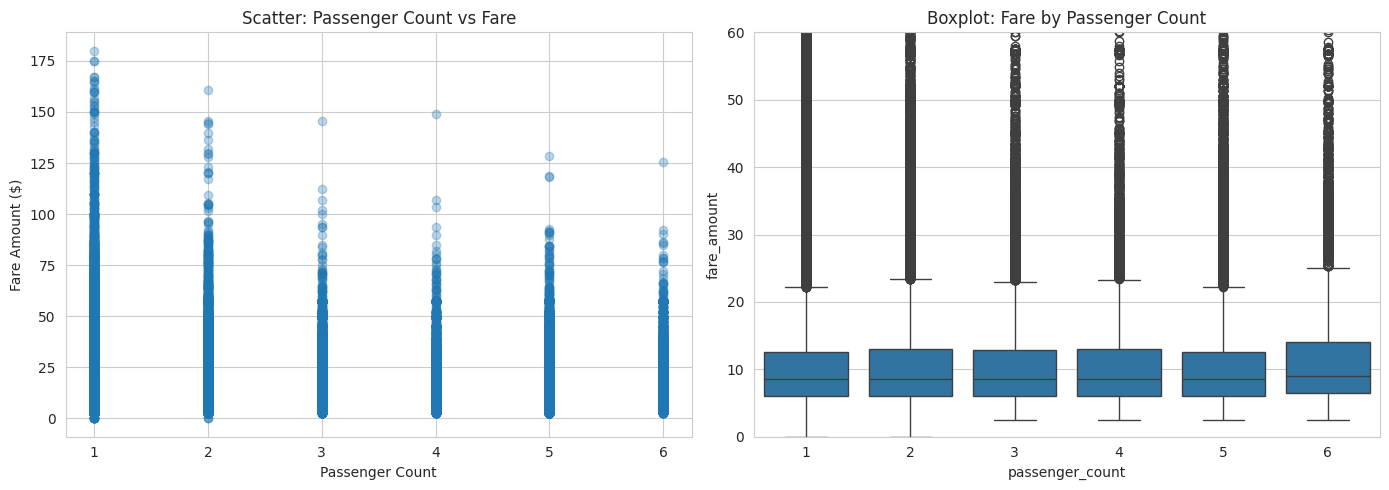

                  count   mean  median
passenger_count                       
1                338568  11.19     8.5
2                 72492  11.81     8.5
3                 21328  11.47     8.5
4                 10377  11.69     8.5
5                 34598  11.21     8.5
6                 10382  12.34     9.0


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_clean['passenger_count'], df_clean['fare_amount'], alpha=0.3)
axes[0].set_xlabel('Passenger Count'); axes[0].set_ylabel('Fare Amount ($)')
axes[0].set_title('Scatter: Passenger Count vs Fare')

sns.boxplot(data=df_clean, x='passenger_count', y='fare_amount', ax=axes[1])
axes[1].set_title('Boxplot: Fare by Passenger Count')
axes[1].set_ylim(0, 60)

plt.tight_layout()
plt.show()

print(df_clean.groupby('passenger_count')['fare_amount'].agg(['count','mean','median']).round(2))

**Interpretation:** Average fare is very close across all passenger-count groups, with no clear upward trend. **Passenger count is not a strong driver of fare** — pricing likely depends on distance and time, not headcount.
**Limitation:** Most trips have a single passenger, so the other groups have small sample sizes.

### Q2) Does car condition affect the fare?
- `Car Condition`: categorical
- `fare_amount`: numerical
- **Plot choice:** Boxplot — shows distribution and outliers per category.

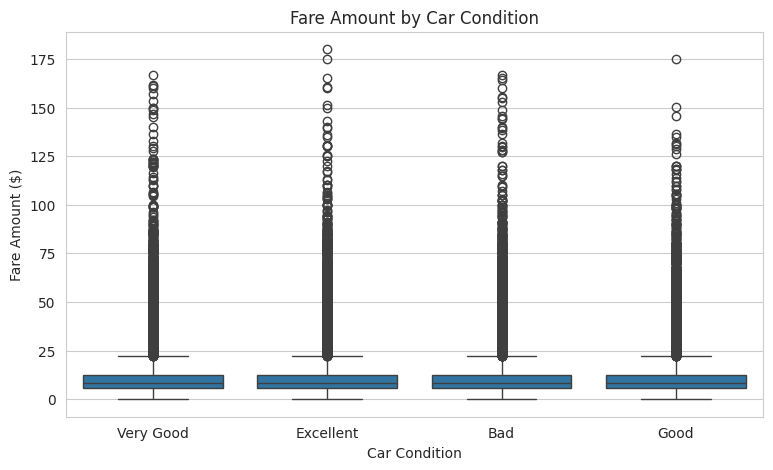

                count   mean  median
Car Condition                       
Bad            121962  11.29     8.5
Excellent      121708  11.33     8.5
Good           121896  11.32     8.5
Very Good      122179  11.39     8.5


In [57]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df_clean, x='Car Condition', y='fare_amount')
plt.title('Fare Amount by Car Condition')
plt.xlabel('Car Condition'); plt.ylabel('Fare Amount ($)')
plt.show()

print(df_clean.groupby('Car Condition')['fare_amount'].agg(['count','mean','median']).round(2))

**Interpretation:** Averages are very close across car conditions. **Car condition has no clear effect on the fare** — makes sense since pricing is based on a fixed distance/time model, not vehicle condition.

### Q3) At what hour of the day are fares typically highest?
- `hour`: numerical, ordered (0-23)
- `fare_amount`: numerical
- **Plot choice:** Line Chart — appropriate for trends over ordered/time data.

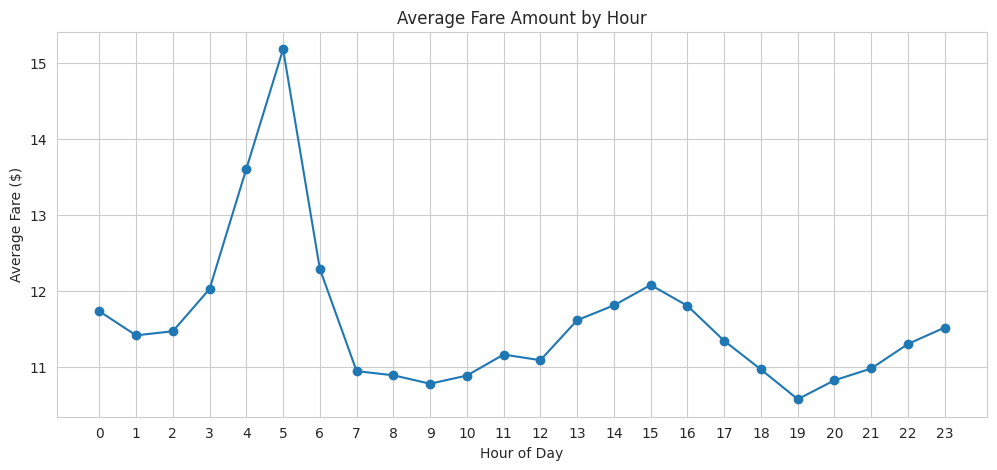

In [58]:
hourly_fare = df_clean.groupby('hour')['fare_amount'].mean()

plt.figure(figsize=(12,5))
plt.plot(hourly_fare.index, hourly_fare.values, marker='o')
plt.xlabel('Hour of Day'); plt.ylabel('Average Fare ($)')
plt.title('Average Fare Amount by Hour')
plt.xticks(range(24)); plt.grid(True)
plt.show()

**Interpretation:** Average fare rises slightly during early morning hours and the evening rush, likely due to longer trips (e.g. airport runs) during those windows.

### Q4) Does traffic condition affect the trip fare?
- `Traffic Condition`: categorical
- `fare_amount`: numerical
- **Plot choice:** Boxplot.

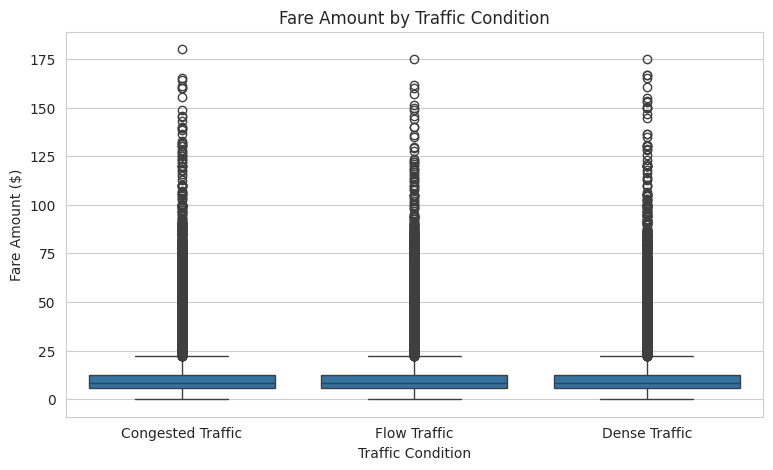

                    count   mean  median
Traffic Condition                       
Congested Traffic  162808  11.37     8.5
Dense Traffic      162473  11.33     8.5
Flow Traffic       162464  11.30     8.5


In [59]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df_clean, x='Traffic Condition', y='fare_amount')
plt.title('Fare Amount by Traffic Condition')
plt.xlabel('Traffic Condition'); plt.ylabel('Fare Amount ($)')
plt.show()

print(df_clean.groupby('Traffic Condition')['fare_amount'].agg(['count','mean','median']).round(2))

**Interpretation:** The difference between traffic conditions is small — fare in this dataset appears to be driven more by distance than by traffic level itself.

### Q5) Is trip distance the strongest predictor of the fare amount?
- `distance`: numerical
- `fare_amount`: numerical
- **Plot choice:** Scatter Plot + correlation coefficient.

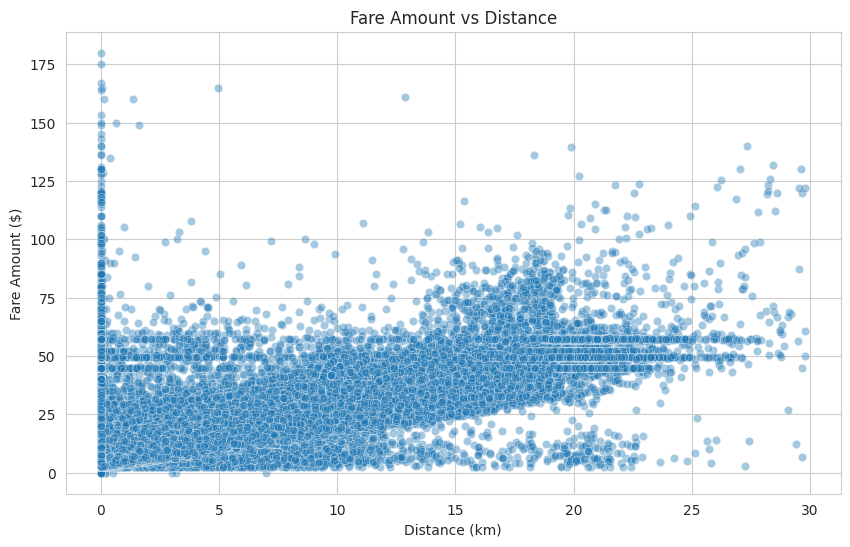

Correlation: 0.83


In [60]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean[df_clean['distance'] <= 30], x='distance', y='fare_amount', alpha=0.4)
plt.title('Fare Amount vs Distance')
plt.xlabel('Distance (km)'); plt.ylabel('Fare Amount ($)')
plt.show()

print("Correlation:", df_clean[['distance','fare_amount']].corr().round(3).iloc[0,1])

**Interpretation:** There's a clear, strong, roughly linear relationship — fare increases fairly consistently with distance. **Distance is indeed the strongest predictor of fare** among everything examined so far.

### Q6) At what hour of the day are ride requests most frequent? *(different from Q3 — this is about count, not price)*
- `hour`: discrete numerical
- **Count**, not fare
- **Plot choice:** Count Plot / Bar Chart.

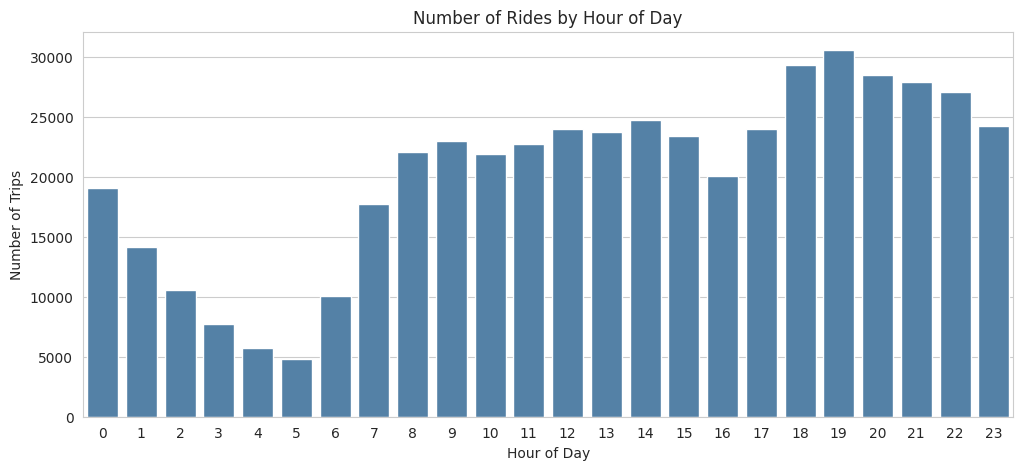

In [61]:
plt.figure(figsize=(12,5))
sns.countplot(data=df_clean, x='hour', color='steelblue')
plt.title('Number of Rides by Hour of Day')
plt.xlabel('Hour of Day'); plt.ylabel('Number of Trips')
plt.show()

**Interpretation:** Ride demand peaks in the evening (post-work/dinner hours) and drops sharply in the early-morning hours — a pattern consistent with typical daily mobility.

### Q7) Does weather condition influence the average trip distance?
- `Weather`: categorical
- `distance`: numerical
- **Plot choice:** Boxplot.

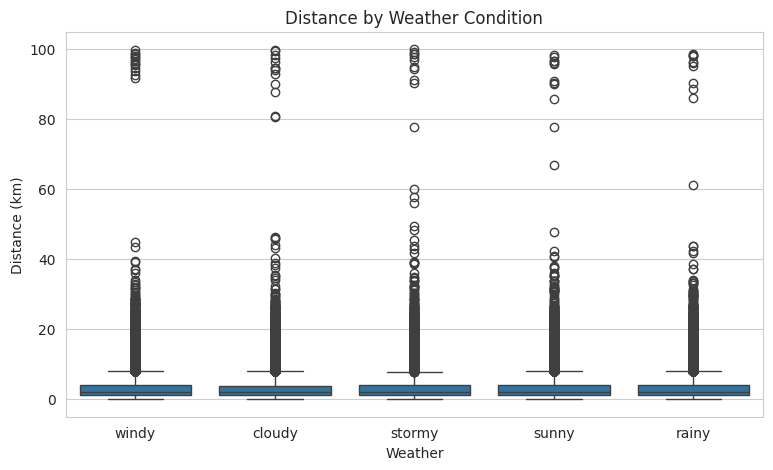

         count  mean  median
Weather                     
cloudy   97561  3.33    2.14
rainy    97583  3.33    2.16
stormy   97552  3.33    2.15
sunny    97917  3.34    2.16
windy    97132  3.33    2.16


In [62]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df_clean, x='Weather', y='distance')
plt.title('Distance by Weather Condition')
plt.xlabel('Weather'); plt.ylabel('Distance (km)')
plt.show()

print(df_clean.groupby('Weather')['distance'].agg(['count','mean','median']).round(2))

**Interpretation:** Distance distributions are similar across weather conditions, so weather doesn't appear to meaningfully change how far people choose to travel.

### Q8) Are rides that start closer to airports generally more expensive?
- `jfk_dist` (or `ewr_dist` / `lga_dist`): numerical
- `fare_amount`: numerical
- **Plot choice:** Scatter Plot.

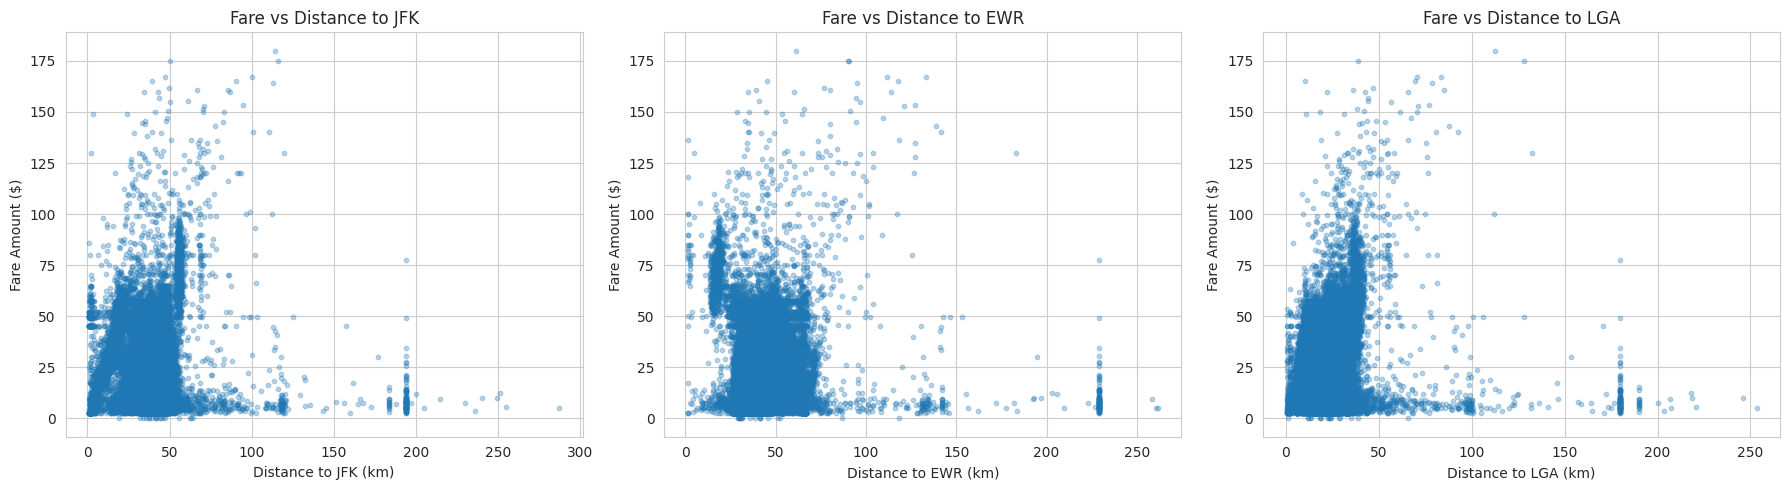

jfk_dist      -0.375
ewr_dist       0.340
lga_dist       0.098
fare_amount    1.000
Name: fare_amount, dtype: float64


In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, col, name in zip(axes, ['jfk_dist','ewr_dist','lga_dist'], ['JFK','EWR','LGA']):
    ax.scatter(df_clean[col], df_clean['fare_amount'], alpha=0.3, s=10)
    ax.set_xlabel(f'Distance to {name} (km)')
    ax.set_ylabel('Fare Amount ($)')
    ax.set_title(f'Fare vs Distance to {name}')

plt.tight_layout()
plt.show()

print(df_clean[['jfk_dist','ewr_dist','lga_dist','fare_amount']].corr()['fare_amount'].round(3))

Interpretation: Distance to JFK shows a moderate negative correlation with fare (-0.375) — trips closer to JFK tend to have higher fares, which is consistent with JFK's known flat-rate pricing for airport trips. EWR shows a similar moderate pattern (0.34), while LGA shows almost no relationship (0.098), suggesting it's priced more like a regular metered trip.

## 4. Extra Questions (Our Own)

### Q9) Does the day of the week affect the fare?
- `weekday`: ordered categorical (0=Mon ... 6=Sun)
- `fare_amount`: numerical
- **Plot choice:** Boxplot.

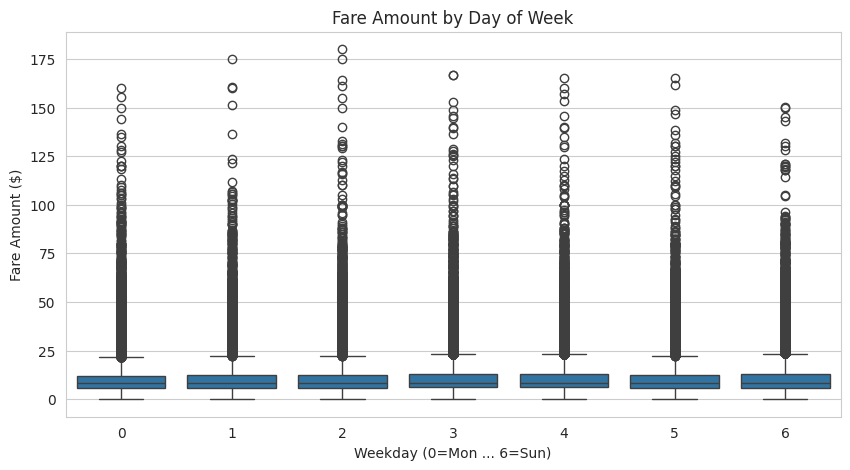

In [64]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean, x='weekday', y='fare_amount')
plt.title('Fare Amount by Day of Week')
plt.xlabel('Weekday (0=Mon ... 6=Sun)'); plt.ylabel('Fare Amount ($)')
plt.show()

**Interpretation:** No major difference between weekdays — fare doesn't seem to be strongly affected by the day of the week itself.

### Q10) Does the time of year (month) affect the average fare?
- `month`: ordered numerical (1-12)
- `fare_amount`: numerical
- **Plot choice:** Line Chart.

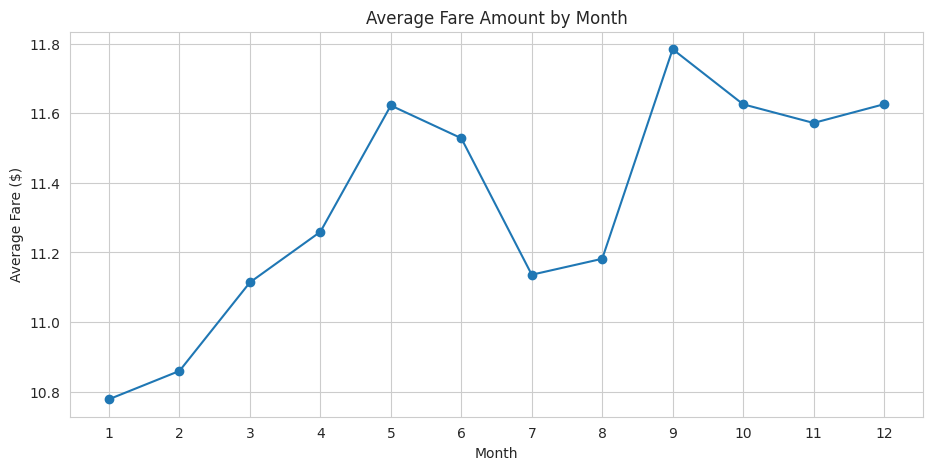

In [65]:
monthly_fare = df_clean.groupby('month')['fare_amount'].mean()

plt.figure(figsize=(11,5))
plt.plot(monthly_fare.index, monthly_fare.values, marker='o')
plt.xlabel('Month'); plt.ylabel('Average Fare ($)')
plt.title('Average Fare Amount by Month')
plt.xticks(range(1,13)); plt.grid(True)
plt.show()

**Interpretation:** Average fare stays fairly stable across the year, with no obvious seasonal pattern.

## 5. Distributions Overview

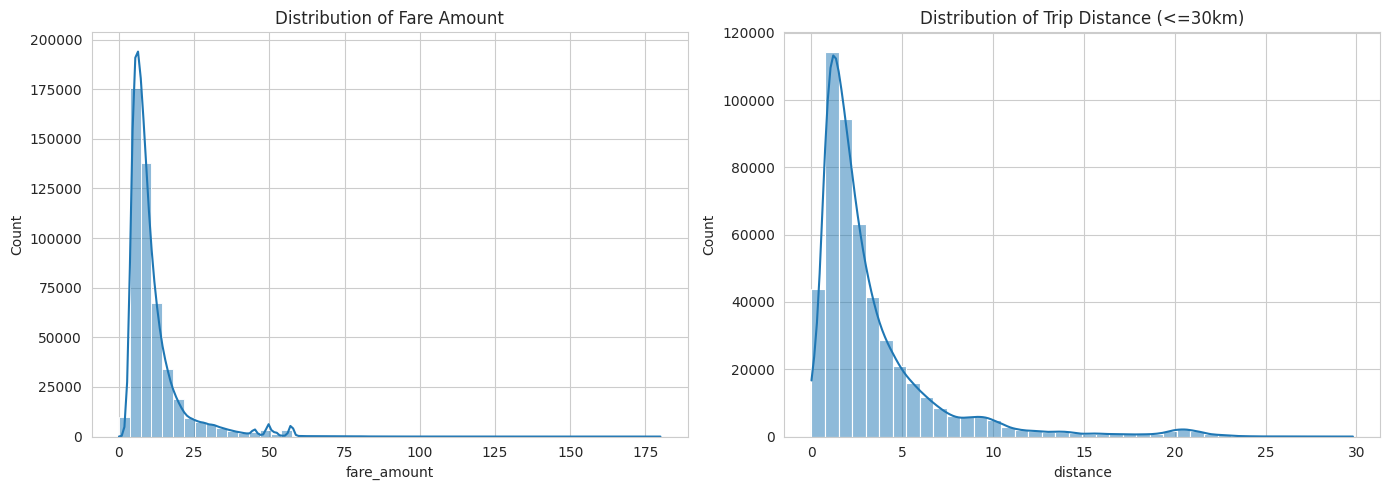

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df_clean['fare_amount'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Fare Amount')
sns.histplot(df_clean[df_clean['distance']<=30]['distance'], bins=40, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Trip Distance (<=30km)')
plt.tight_layout()
plt.show()

**Interpretation:** Both `fare_amount` and `distance` are **right-skewed** (most trips are short and cheap, with a long tail of longer, pricier trips) — this will influence model choice in Task 2.

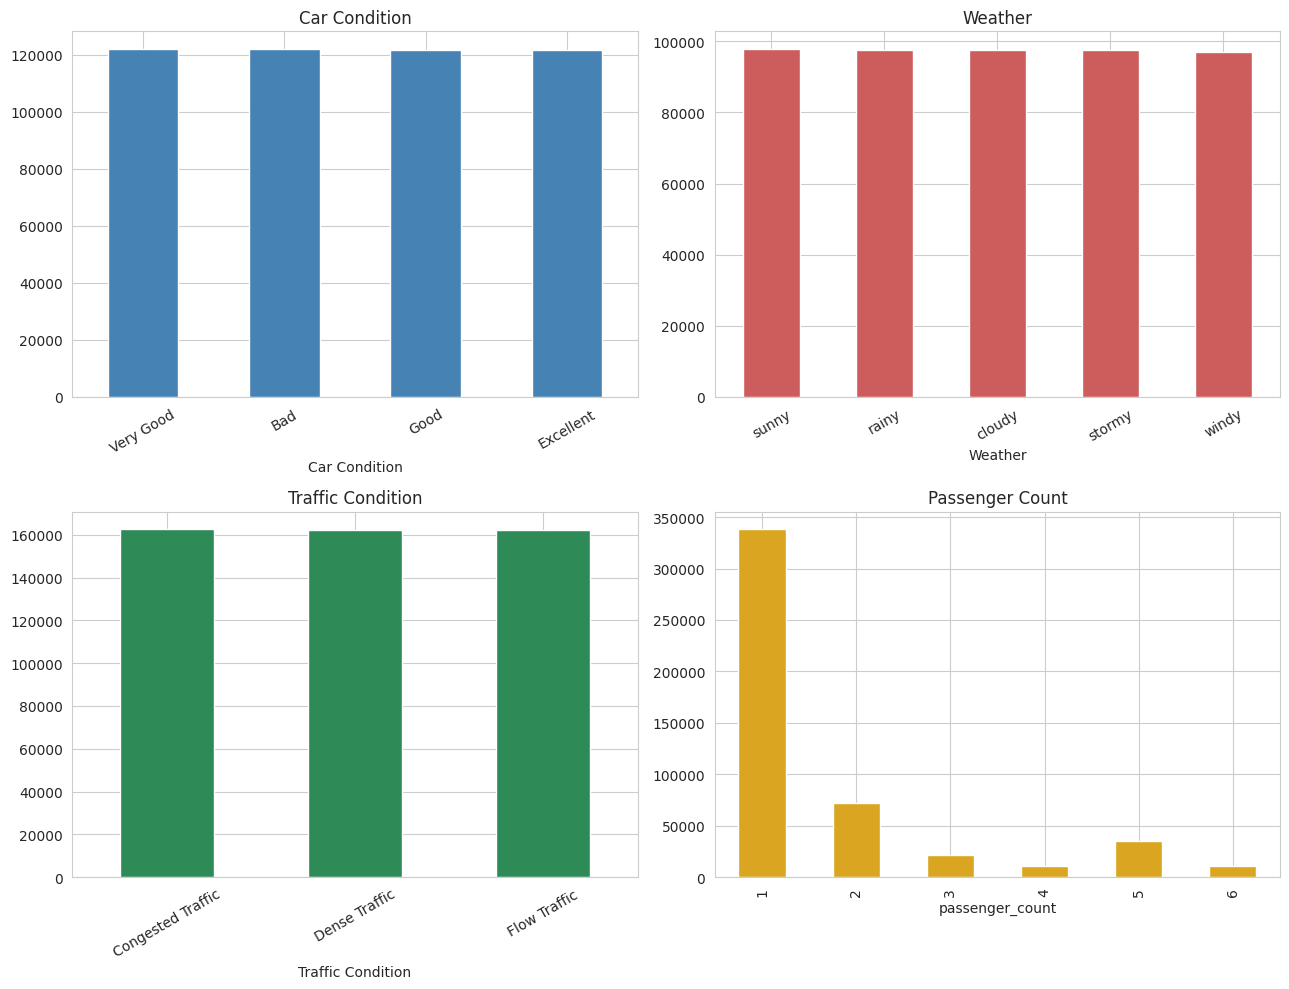

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(13,10))
df_clean['Car Condition'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Car Condition'); axes[0,0].tick_params(axis='x', rotation=30)

df_clean['Weather'].value_counts().plot(kind='bar', ax=axes[0,1], color='indianred')
axes[0,1].set_title('Weather'); axes[0,1].tick_params(axis='x', rotation=30)

df_clean['Traffic Condition'].value_counts().plot(kind='bar', ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Traffic Condition'); axes[1,0].tick_params(axis='x', rotation=30)

df_clean['passenger_count'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='goldenrod')
axes[1,1].set_title('Passenger Count')

plt.tight_layout()
plt.show()

**Interpretation:** Categorical features are fairly balanced (no rare category needing special handling), and most trips have a single passenger.

## 6. Correlation Heatmap — Which Features Relate Most to Fare?

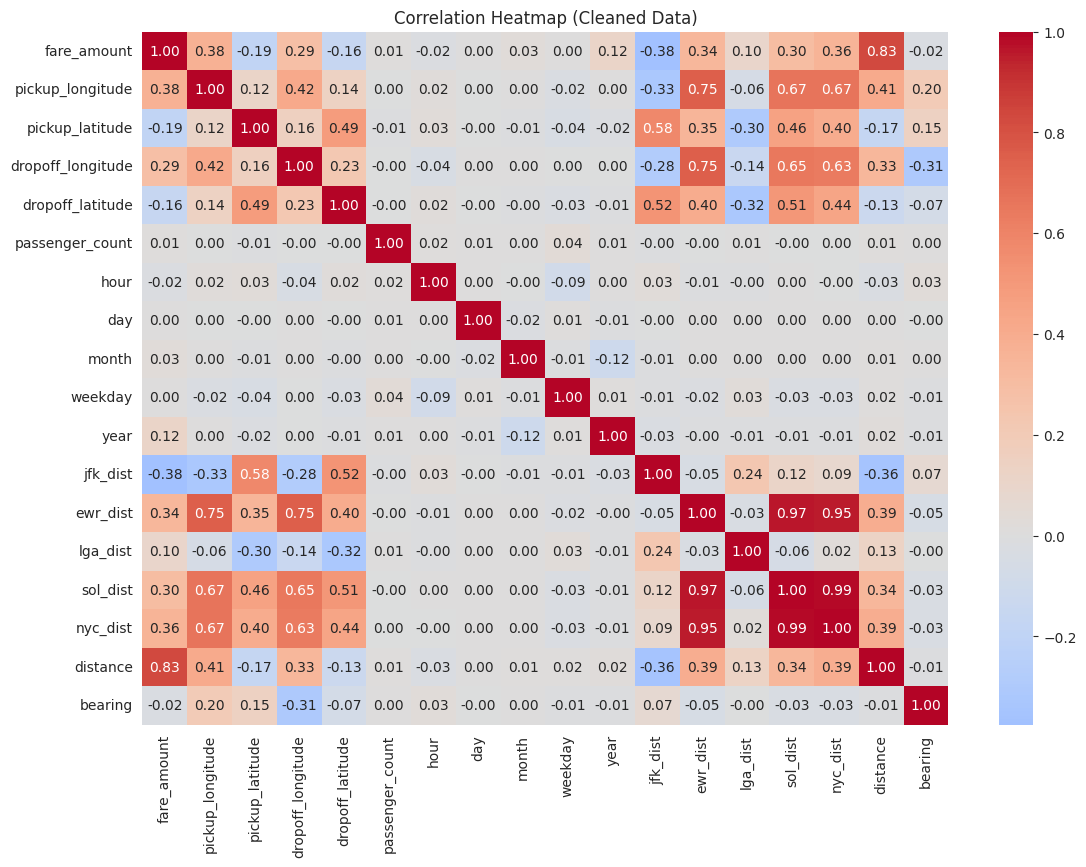

In [68]:
numeric_cols = df_clean.select_dtypes(include='number').drop(columns=['key'], errors='ignore')

plt.figure(figsize=(13,9))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Cleaned Data)')
plt.show()

**Interpretation:** `distance` is by far the strongest driver of `fare_amount` (confirming Q5). Other variables (airport distances, hour, month) have weak individual correlation with fare.

## 7. EDA Summary

- **Strongest predictor of fare:** distance — a clear, strong linear relationship.
- **Weak factors:** passenger count, car condition, traffic condition, weather, weekday, month — all have limited individual effect on fare in this dataset.
- **Hour** has a mild effect on average fare (linked to longer rush-hour trips), and a clearer effect on **ride demand** (peaks in the evening).
- **Airport proximity** doesn't follow the same pricing logic as regular trips (likely flat-rate pricing) — worth deeper investigation at the modeling stage.
- The data contained real quality issues (bad coordinates, unrealistic fares) — the cleaning we performed was necessary before any further analysis.

**Next step:** these insights will guide Task 2 — distance will be the most important feature, and we should consider engineering additional features for airport trips and rush-hour periods.